# Example
using resources from https://huggingface.co/docs/transformers/model_doc/wav2vec2 ingest wav files, embed them and display results

In [28]:
from umap import UMAP
from tqdm import tqdm
import matplotlib.pyplot as plt
import librosa
from glob import glob
import torch
import numpy as np
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC, Wav2Vec2Model

fnames= glob("/Users/gary/Downloads/LibriSpeech/train-clean-100/3*/**/*")
len(fnames)

3732

In [29]:

#load model and processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-960h")
model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-large-960h")
         

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of the model checkpoint at facebook/wav2vec2-large-960h were not used when initializing Wav2Vec2Model: ['lm_head.weight', 'lm_head.bias']
- This IS expected if you are initializing Wav2Vec2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h 

In [30]:
# retrieve logits
x_train=[]
N = 100
for f in tqdm(fnames[:N]):
    try:
        x, sr = librosa.load(f, sr=16000) 
        input_values = processor(x, sampling_rate=16000, return_tensors="pt", padding="longest").input_values  # Batch size 1
        outputs = model(input_values, output_hidden_states=True)
        x_train.append(np.squeeze(outputs['hidden_states'][1].detach().numpy()))
    except:
        pass


 21%|███████████████▉                                                            | 21/100 [00:32<02:08,  1.63s/it]/var/folders/_q/tcgs8dld2dx2rf07xv0wgmk00000gp/T/ipykernel_34793/736680620.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  x, sr = librosa.load(f, sr=16000)
/Users/gary/miniconda3/envs/tf_hf_umap/lib/python3.8/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|███████████████████████████████████████████████████████████████████████████| 100/100 [02:25<00:00,  1.45s/it]


In [31]:
x_train = np.vstack([x for x in x_train])
mapper = UMAP().fit_transform(x_train)

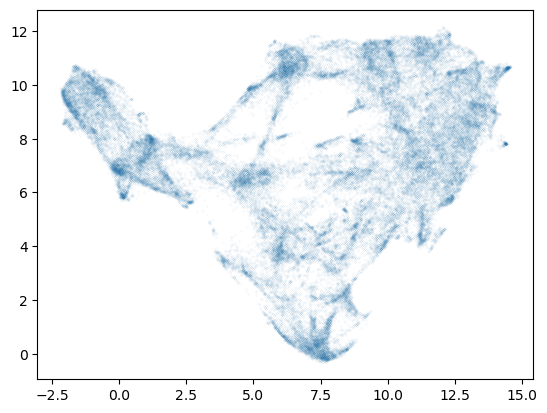

In [33]:
plt.scatter(mapper[:,0], mapper[:,1], s=.001)

In [26]:
#logits = model(input_values ).logits
logits = outputs.logits

# take argmax and decode
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)
transcription

["WERE IN THE DOCTOR'S OPINION SURE TO CARRY HIM OFF BUT ON THE SEVENTH DAY HE ATE WITH PLEASURE A PIECE OF BREAD WITH SOME TEA AND THE DOCTOR NOTICED THAT HIS TEMPERATURE WAS LOWER HE HAD REGAINED CONSCIOUSNESS THAT MORNING THE FIRST NIGHT AFTER THEY LEFT MOSCOW"]

In [63]:
from datasets import Dataset , load_dataset, load_from_disk
fnames = glob("raw_wav/*")
fnames = glob("raw_wav/*")
data = {"file": fnames}
dataset = Dataset.from_dict(data)
dataset.save_to_disk("wav_dataset", format='json')

TypeError: save_to_disk() got an unexpected keyword argument 'format'

In [64]:
import pandas as pd
dataset_pandas = dataset.to_pandas()
dataset_pandas.to_csv("wav_dataset.csv", index=False)

In [70]:
dataset = load_dataset("csv", data_files="wav_dataset.csv")

Found cached dataset csv (/Users/gary/.cache/huggingface/datasets/csv/default-910cd4edfd3be787/0.0.0/eea64c71ca8b46dd3f537ed218fc9bf495d5707789152eb2764f5c78fa66d59d)


  0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
from datasets import Dataset, DatasetDict, load_dataset, register_caching_custom_urls
import pandas as pd
register_caching_custom_urls({"my_dataset_name": "file://wav_dataset.csv"})

# Load the registered dataset
dataset = load_dataset("my_dataset_name")

ImportError: cannot import name 'register_caching_custom_urls' from 'datasets' (/Users/gary/miniconda3/envs/tf_hf_umap/lib/python3.8/site-packages/datasets/__init__.py)

ref:  https://discuss.huggingface.co/t/wav2vec2-hidden-states/32654
